Shape: (411025, 177)
Beta-only shape: (411025, 89)
Transposed shape: (88, 411025)
Filtered shape: (88, 5000)
(88, 5000)
Explained variance: [0.21927412 0.17298708]


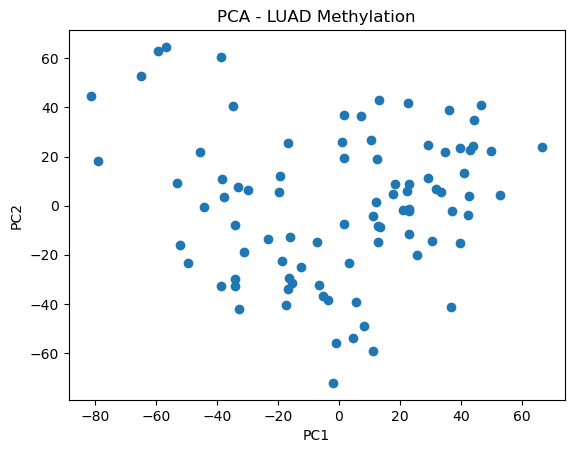

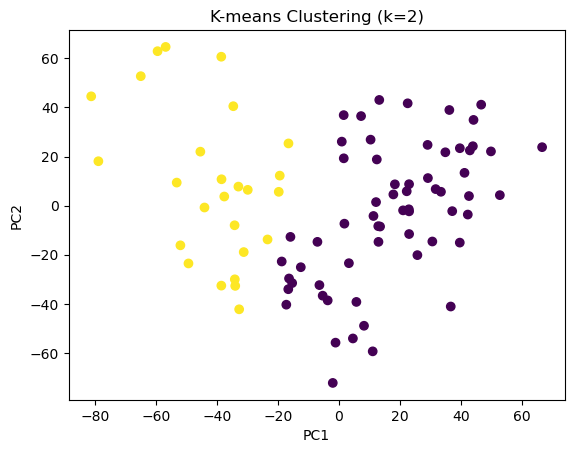

Explained variance ratio: [0.21927412 0.17298708]


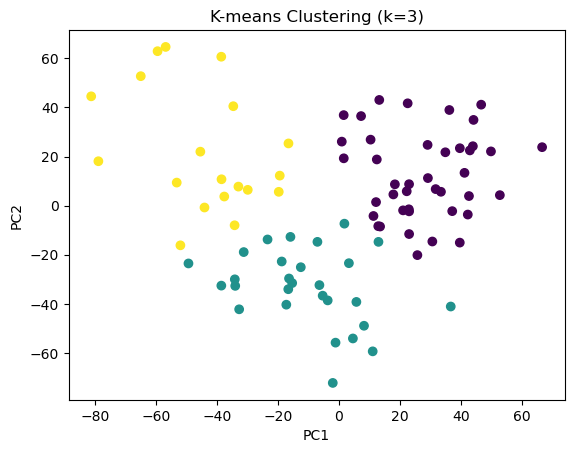

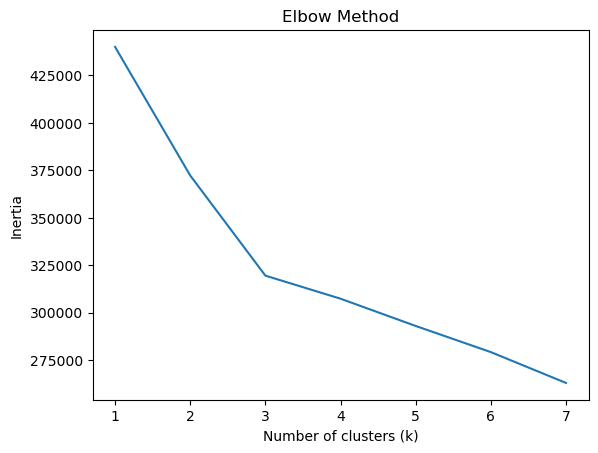

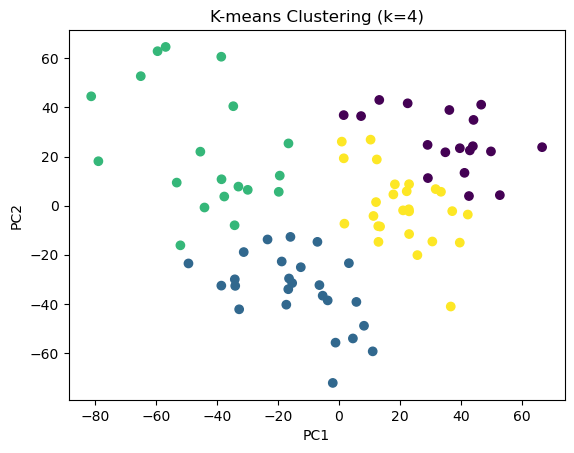

In [24]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

file_path = "/mnt/c/Users/Surface/Desktop/Project2/GSE180060_processed_data.txt"

df = pd.read_csv(file_path, sep="\t")

print("Shape:", df.shape)
df.head()

beta_cols = [col for col in df.columns if "Avg Beta" in col]

df_beta = df[["ID_REF"] + beta_cols]

print("Beta-only shape:", df_beta.shape)
df_beta.head()

df_beta.set_index("ID_REF", inplace=True)

df_beta = df_beta.T

print("Transposed shape:", df_beta.shape)
df_beta.head()



# Calculated variance of each CpG across patients
variances = df_beta.var(axis=0)

# i have Selected top 5000 most variable CpGs
top_cpgs = variances.sort_values(ascending=False).head(5000).index

df_filtered = df_beta[top_cpgs]

print("Filtered shape:", df_filtered.shape)

# Scaled the data using StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_filtered)

print(X_scaled.shape)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance:", pca.explained_variance_ratio_)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - LUAD Methylation")
plt.show()


kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-means Clustering (k=2)")
plt.show()



pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)



kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-means Clustering (k=3)")
plt.show()


inertia = []

for k in range(1, 8):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure()
plt.plot(range(1, 8), inertia)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-means Clustering (k=4)")
plt.show()